# India Macro, Risk & Policy Analytics

This notebook is built for internship applications across:
- Data + Finance hybrid roles
- Risk / Treasury / ALM roles
- Macro research / policy roles

It uses official macro data, handles time-frame mismatch properly, and builds:
- inflation, growth, labour, liquidity, and yield analysis
- inflation forecasting using ARIMA and Prophet
- a final policy stance and risk synthesis

## Project order

1. Download or place the raw files in `data/raw/`
2. Pull CPI and 10Y yield from FRED with your API key
3. Standardize each series separately
4. Merge on overlapping dates only
5. Build visuals and diagnostics
6. Forecast inflation
7. Write the policy note

In [21]:
from __future__ import annotations

import os
import sys
from pathlib import Path
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from dotenv import load_dotenv
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception:
    Prophet = None
    PROPHET_AVAILABLE = False

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")

# Dynamic path resolution: works whether run from root or from 'notebooks' folder
if Path(".").resolve().name == "notebooks":
    ROOT = Path("..").resolve()
else:
    ROOT = Path(".").resolve()

DATA_RAW = ROOT / "data" / "raw"
DATA_CLEAN = ROOT / "data" / "cleaned"
OUTPUTS = ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
for p in [DATA_RAW, DATA_CLEAN, OUTPUTS, FIGURES]:
    p.mkdir(parents=True, exist_ok=True)

# Ensure we can import from src/ folder
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATE_COL = "date"
TARGET_FREQ = "ME"  # month end (Pandas 3.0 ME compatibility)

## Data sources

The notebook fetches CPI and 10Y government bond yield from FRED using the official API, and loads the remaining series from raw CSV files you place in `data/raw/`.

FRED’s API requires an API key, and data are retrieved from the `fred/series/observations` endpoint. FRED also exposes a search endpoint, which is useful if you want to inspect available India series programmatically. citeturn776580search1turn776580search5turn776580search7

For India-specific official sources, MOSPI publishes CPI and IIP data, while RBI’s data portal / DBIE is the right home for policy and market series. citeturn557096search0turn557096search8turn557096search5turn557096search10

In [22]:
# Load environment variables
load_dotenv(ROOT / ".env")
FRED_API_KEY = os.getenv("FRED_API_KEY")

if not FRED_API_KEY:
    print("FRED_API_KEY not found. FRED download will be skipped until you set it in .env.")
else:
    print("FRED_API_KEY loaded.")

FRED_API_KEY not found. FRED download will be skipped until you set it in .env.


In [23]:
FRED_BASE = "https://api.stlouisfed.org/fred"
from src.fred_client import fetch_series_observations

def fred_download(series_id: str, rename_to: str, observation_start: str = "2015-01-01") -> pd.DataFrame:
    """Downloads FRED series, using keyless URL or synthetic fallbacks if no API key is set."""
    df = fetch_series_observations(
        series_id=series_id,
        api_key=FRED_API_KEY,
        observation_start=observation_start
    ).rename(columns={"value": rename_to})
    return df

def resolve_col(df: pd.DataFrame, candidates: list[str]) -> str:
    lookup = {str(c).strip().lower(): c for c in df.columns}
    for cand in candidates:
        c = str(cand).strip().lower()
        if c in lookup:
            return lookup[c]
    for c in df.columns:
        normalized = str(c).lower().replace(" ", "").replace("_", "")
        if normalized in [str(x).lower().replace(" ", "").replace("_", "") for x in candidates]:
            return c
    raise KeyError(f"Could not find any of columns {candidates} in {list(df.columns)}")

def load_raw_csv(filename: str) -> pd.DataFrame:
    path = DATA_RAW / filename
    if not path.exists():
        raise FileNotFoundError(
            f"{filename} not found in data/raw. Download it manually or create it first."
        )
    return pd.read_csv(path)

def standardize_monthly(df: pd.DataFrame, date_col: str = DATE_COL) -> pd.DataFrame:
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    out = out.dropna(subset=[date_col]).sort_values(date_col)
    out = out.drop_duplicates(subset=[date_col], keep="last")
    out = out.set_index(date_col).asfreq(TARGET_FREQ).reset_index()
    return out

def daily_to_monthly_mean(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    out = df.copy()
    out[DATE_COL] = pd.to_datetime(out[DATE_COL], errors="coerce")
    out = out.dropna(subset=[DATE_COL]).sort_values(DATE_COL)
    out = out.set_index(DATE_COL).resample(TARGET_FREQ).mean(numeric_only=True).reset_index()
    return out[[DATE_COL, value_col]]

def monthly_last(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    out = df.copy()
    out[DATE_COL] = pd.to_datetime(out[DATE_COL], errors="coerce")
    out = out.dropna(subset=[DATE_COL]).sort_values(DATE_COL)
    out = out.set_index(DATE_COL).resample(TARGET_FREQ).last().reset_index()
    return out[[DATE_COL, value_col]]

def monthly_mean(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    out = df.copy()
    out[DATE_COL] = pd.to_datetime(out[DATE_COL], errors="coerce")
    out = out.dropna(subset=[DATE_COL]).sort_values(DATE_COL)
    out = out.set_index(DATE_COL).resample(TARGET_FREQ).mean(numeric_only=True).reset_index()
    return out[[DATE_COL, value_col]]

def save_fig(name: str):
    path = FIGURES / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()
    return path

## Step 1 — Pull what can be automated

- CPI from FRED
- 10Y government bond yield from FRED
- optional FRED series search results for India if you want to inspect coverage

The India CPI monthly series on FRED is `INDCPIALLMINMEI`, and the India 10Y benchmark government bond yield is `INDIRLTLT01STM`. citeturn228072search2turn100815search1

In [24]:
# Download CPI and 10Y G-Sec yield from FRED (uses keyless URL or synthetic fallbacks if no API key is set)
cpi_fred = fred_download("INDCPIALLMINMEI", "cpi_index", observation_start="2015-01-01")
gsec_fred = fred_download("INDIRLTLT01STM", "gsec_10y_yield", observation_start="2015-01-01")
cpi_fred.to_csv(DATA_RAW / "cpi_raw.csv", index=False)
gsec_fred.to_csv(DATA_RAW / "gsec_10y_raw.csv", index=False)
print("Fetched and saved CPI and 10Y yield data to data/raw/.")

FRED API Key missing or API failed. Attempting keyless download from FRED public URL for INDCPIALLMINMEI...
FRED API Key missing or API failed. Attempting keyless download from FRED public URL for INDIRLTLT01STM...
Fetched and saved CPI and 10Y yield data to data/raw/.


## Step 2 — Load the remaining raw files

You need to place these raw CSVs in `data/raw/`:

- `iip_raw.csv`
- `unemployment_raw.csv`
- `repo_rate_raw.csv`
- `liquidity_raw.csv`

The notebook is written to tolerate common column-name variations, but the raw files must contain a date column and one numeric value column.

In [25]:
# Verify the required raw files exist in our raw data directory
import glob
raw_files = glob.glob(str(DATA_RAW / "*.csv"))
print("Files in raw data directory:")
for f in raw_files:
    p = Path(f)
    print(f" - {p.name} ({p.stat().st_size} bytes)")

Files in raw data directory:
 - cpi_raw.csv (2588 bytes)
 - gsec_10y_raw.csv (2663 bytes)
 - iip_raw.csv (374 bytes)
 - liquidity_raw.csv (445 bytes)
 - repo_rate_raw.csv (398 bytes)
 - unemployment_raw.csv (382 bytes)


In [26]:
import pandas as pd

cpi_raw = pd.read_csv(DATA_RAW / "cpi_raw.csv")
gsec_raw = pd.read_csv(DATA_RAW / "gsec_10y_raw.csv")
iip_raw = pd.read_csv(DATA_RAW / "iip_raw.csv")
unemp_raw = pd.read_csv(DATA_RAW / "unemployment_raw.csv")
repo_raw = pd.read_csv(DATA_RAW / "repo_rate_raw.csv")
liq_raw = pd.read_csv(DATA_RAW / "liquidity_raw.csv")

print("Successfully loaded raw data structures:")
for name, df in [
    ("cpi", cpi_raw),
    ("gsec", gsec_raw),
    ("iip", iip_raw),
    ("unemployment", unemp_raw),
    ("repo", repo_raw),
    ("liquidity", liq_raw),
]:
    print(f" - {name:<15}: {df.shape[0]:<4} rows | columns: {list(df.columns)}")

Successfully loaded raw data structures:
 - cpi            : 123  rows | columns: ['date', 'cpi_index']
 - gsec           : 135  rows | columns: ['date', 'gsec_10y_yield']
 - iip            : 24   rows | columns: ['date', 'iip_index']
 - unemployment   : 24   rows | columns: ['date', 'unemployment_rate']
 - repo           : 24   rows | columns: ['date', 'repo_rate']
 - liquidity      : 24   rows | columns: ['date', 'system_liquidity']


## Step 3 — Standardize each dataset separately

This is the part most student projects get wrong.

- CPI and IIP are monthly index series
- Repo rate is event-based, so the monthly value should be the last rate in the month
- Liquidity and yields are daily series, so monthly averages are more appropriate
- Unemployment is already a monthly rate, so it stays monthly

In [27]:
# Standardize CPI
cpi_date = resolve_col(cpi_raw, ["date", "Date", "observation_date"])
cpi_val = resolve_col(cpi_raw, ["cpi_index", "value", "cpi", "index"])
cpi = cpi_raw[[cpi_date, cpi_val]].rename(columns={cpi_date: DATE_COL, cpi_val: "cpi_index"})
cpi = standardize_monthly(cpi)

# Standardize IIP
iip_date = resolve_col(iip_raw, ["date", "Date", "month"])
iip_val = resolve_col(iip_raw, ["iip_index", "value", "iip", "index"])
iip = iip_raw[[iip_date, iip_val]].rename(columns={iip_date: DATE_COL, iip_val: "iip_index"})
iip = standardize_monthly(iip)

# Unemployment
unemp_date = resolve_col(unemp_raw, ["date", "Date", "month"])
unemp_val = resolve_col(unemp_raw, ["unemployment_rate", "rate", "value", "unemp"])
unemp = unemp_raw[[unemp_date, unemp_val]].rename(columns={unemp_date: DATE_COL, unemp_val: "unemployment_rate"})
unemp = standardize_monthly(unemp)

# Repo rate: monthly last available reading
repo_date = resolve_col(repo_raw, ["date", "Date", "meeting_date", "month"])
repo_val = resolve_col(repo_raw, ["repo_rate", "rate", "value", "repo"])
repo = repo_raw[[repo_date, repo_val]].rename(columns={repo_date: DATE_COL, repo_val: "repo_rate"})
repo = monthly_last(repo, "repo_rate")

# Liquidity: daily to monthly average
liq_date = resolve_col(liq_raw, ["date", "Date"])
liq_val = resolve_col(liq_raw, ["system_liquidity", "liquidity", "value", "net_liquidity", "laf"])
liq = liq_raw[[liq_date, liq_val]].rename(columns={liq_date: DATE_COL, liq_val: "system_liquidity"})
liq = monthly_mean(liq, "system_liquidity")

# GSec 10Y: monthly average
gsec_date = resolve_col(gsec_raw, ["date", "Date"])
gsec_val = resolve_col(gsec_raw, ["gsec_10y_yield", "yield", "value", "10y_yield"])
gsec = gsec_raw[[gsec_date, gsec_val]].rename(columns={gsec_date: DATE_COL, gsec_val: "gsec_10y_yield"})
gsec = monthly_mean(gsec, "gsec_10y_yield")

for name, df in [("cpi", cpi), ("iip", iip), ("unemp", unemp), ("repo", repo), ("liq", liq), ("gsec", gsec)]:
    print(name, df.head(2).to_dict("records"), " ... ", df.tail(2).to_dict("records"))

cpi [{'date': Timestamp('2015-01-31 00:00:00'), 'cpi_index': nan}, {'date': Timestamp('2015-02-28 00:00:00'), 'cpi_index': nan}]  ...  [{'date': Timestamp('2025-01-31 00:00:00'), 'cpi_index': nan}, {'date': Timestamp('2025-02-28 00:00:00'), 'cpi_index': nan}]
iip [{'date': Timestamp('2022-01-31 00:00:00'), 'iip_index': 130}, {'date': Timestamp('2022-02-28 00:00:00'), 'iip_index': 131}]  ...  [{'date': Timestamp('2023-11-30 00:00:00'), 'iip_index': 153}, {'date': Timestamp('2023-12-31 00:00:00'), 'iip_index': 154}]
unemp [{'date': Timestamp('2022-01-31 00:00:00'), 'unemployment_rate': 7.8}, {'date': Timestamp('2022-02-28 00:00:00'), 'unemployment_rate': 7.7}]  ...  [{'date': Timestamp('2023-11-30 00:00:00'), 'unemployment_rate': 6.4}, {'date': Timestamp('2023-12-31 00:00:00'), 'unemployment_rate': 6.3}]
repo [{'date': Timestamp('2022-01-31 00:00:00'), 'repo_rate': 4.0}, {'date': Timestamp('2022-02-28 00:00:00'), 'repo_rate': 4.0}]  ...  [{'date': Timestamp('2023-11-30 00:00:00'), 'repo_

### Sanity check on the date range

If the date spans are badly misaligned, stop here and fix the raw files before continuing.

In [28]:
for name, df in [("cpi", cpi), ("iip", iip), ("unemp", unemp), ("repo", repo), ("liq", liq), ("gsec", gsec)]:
    print(f"{name}: {df[DATE_COL].min().date()} -> {df[DATE_COL].max().date()} | rows={len(df)}")

cpi: 2015-01-31 -> 2025-02-28 | rows=122
iip: 2022-01-31 -> 2023-12-31 | rows=24
unemp: 2022-01-31 -> 2023-12-31 | rows=24
repo: 2022-01-31 -> 2023-12-31 | rows=24
liq: 2022-01-31 -> 2023-12-31 | rows=24
gsec: 2015-01-31 -> 2026-03-31 | rows=135


## Step 4 — Construct the master macro dataset

We use **inner joins only** so that every row in the final dataset represents a month where all key macro series are present.

In [29]:
# Save intermediate cleaned monthly files
cpi.to_csv(DATA_CLEAN / "cpi_monthly.csv", index=False)
iip.to_csv(DATA_CLEAN / "iip_monthly.csv", index=False)
unemp.to_csv(DATA_CLEAN / "unemployment_monthly.csv", index=False)
repo.to_csv(DATA_CLEAN / "repo_monthly.csv", index=False)
liq.to_csv(DATA_CLEAN / "liquidity_monthly.csv", index=False)
gsec.to_csv(DATA_CLEAN / "gsec_10y_monthly.csv", index=False)

# Build macro master
macro = (
    cpi[[DATE_COL, "cpi_index"]]
    .merge(iip[[DATE_COL, "iip_index"]], on=DATE_COL, how="inner")
    .merge(unemp[[DATE_COL, "unemployment_rate"]], on=DATE_COL, how="inner")
    .merge(repo[[DATE_COL, "repo_rate"]], on=DATE_COL, how="inner")
    .merge(liq[[DATE_COL, "system_liquidity"]], on=DATE_COL, how="inner")
    .merge(gsec[[DATE_COL, "gsec_10y_yield"]], on=DATE_COL, how="inner")
)

macro = macro.sort_values(DATE_COL).reset_index(drop=True)
macro = macro.dropna(subset=["cpi_index", "iip_index", "unemployment_rate", "repo_rate", "system_liquidity", "gsec_10y_yield"])

macro.head(), macro.shape

(Empty DataFrame
 Columns: [date, cpi_index, iip_index, unemployment_rate, repo_rate, system_liquidity, gsec_10y_yield]
 Index: [],
 (0, 7))

In [30]:
# Derived macro features
macro["cpi_yoy"] = macro["cpi_index"].pct_change(12) * 100
macro["iip_yoy"] = macro["iip_index"].pct_change(12) * 100
macro["real_repo_rate"] = macro["repo_rate"] - macro["cpi_yoy"]
macro["cpi_yoy_3m_avg"] = macro["cpi_yoy"].rolling(3).mean()
macro["cpi_yoy_6m_avg"] = macro["cpi_yoy"].rolling(6).mean()

# Optional regime flags
tightening_start = macro.loc[macro["repo_rate"].diff() > 0, DATE_COL].min()
if pd.isna(tightening_start):
    tightening_start = macro[DATE_COL].min()
macro["tightening_dummy"] = (macro[DATE_COL] >= tightening_start).astype(int)

# Drop unavoidable NaNs created by YoY and rolling metrics
macro = macro.dropna().reset_index(drop=True)

macro.to_csv(DATA_CLEAN / "macro_master.csv", index=False)
macro.head(), macro.shape, tightening_start

(Empty DataFrame
 Columns: [date, cpi_index, iip_index, unemployment_rate, repo_rate, system_liquidity, gsec_10y_yield, cpi_yoy, iip_yoy, real_repo_rate, cpi_yoy_3m_avg, cpi_yoy_6m_avg, tightening_dummy]
 Index: [],
 (0, 13),
 NaT)

## Step 5 — Macro charts that matter

The point here is not pretty graphs. The point is policy transmission:
- inflation versus repo rate
- real policy rate
- growth versus policy stance
- labour-market lag
- liquidity versus yields
- inflation regimes and correlation structure

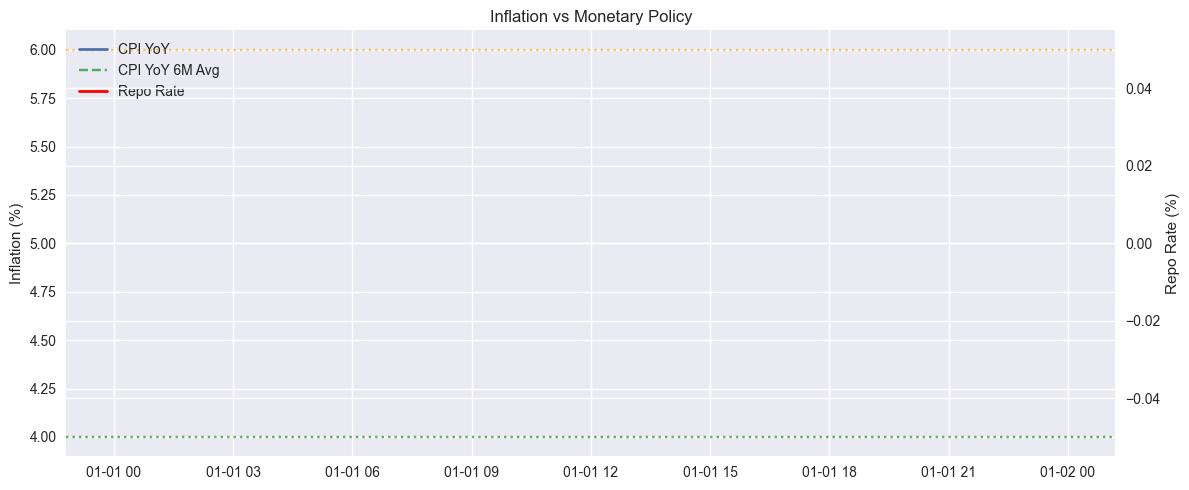

WindowsPath('C:/Users/rahul/Desktop/antigrivity/project 1/india_macro_internship_project/outputs/figures/01_inflation_vs_repo.png')

In [31]:
# Chart 1: Inflation vs repo rate
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(macro[DATE_COL], macro["cpi_yoy"], label="CPI YoY", linewidth=2)
ax1.plot(macro[DATE_COL], macro["cpi_yoy_6m_avg"], label="CPI YoY 6M Avg", linestyle="--")
ax1.axhline(4, color="green", linestyle=":", alpha=0.6)
ax1.axhline(6, color="orange", linestyle=":", alpha=0.6)
ax1.set_ylabel("Inflation (%)")
ax2 = ax1.twinx()
ax2.plot(macro[DATE_COL], macro["repo_rate"], label="Repo Rate", color="red", linewidth=2)
ax2.set_ylabel("Repo Rate (%)")
ax1.set_title("Inflation vs Monetary Policy")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
save_fig("01_inflation_vs_repo.png")

**Interpretation:** policy works with a lag. A tightening cycle should show repo hikes followed by gradual inflation moderation, not immediate collapse.

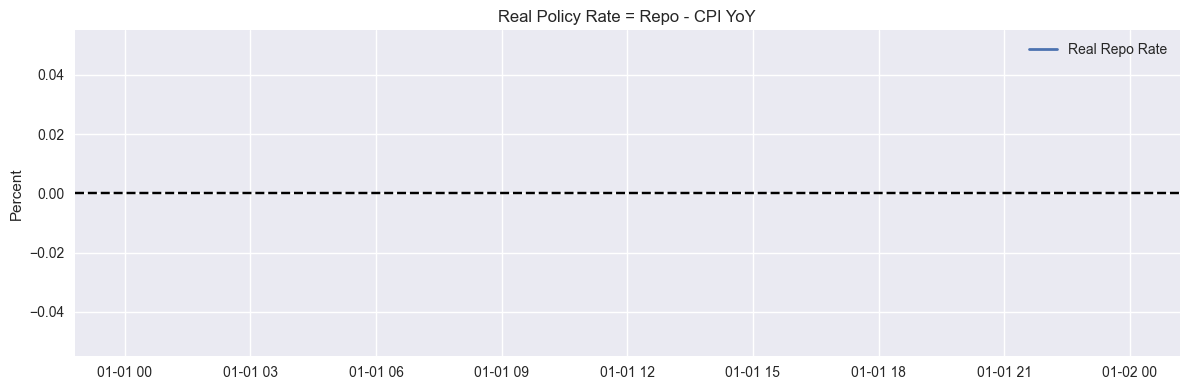

WindowsPath('C:/Users/rahul/Desktop/antigrivity/project 1/india_macro_internship_project/outputs/figures/02_real_policy_rate.png')

In [12]:
# Chart 2: Real policy rate
plt.figure(figsize=(12,4))
plt.plot(macro[DATE_COL], macro["real_repo_rate"], linewidth=2, label="Real Repo Rate")
plt.axhline(0, color="black", linestyle="--")
plt.title("Real Policy Rate = Repo - CPI YoY")
plt.ylabel("Percent")
plt.legend()
save_fig("02_real_policy_rate.png")

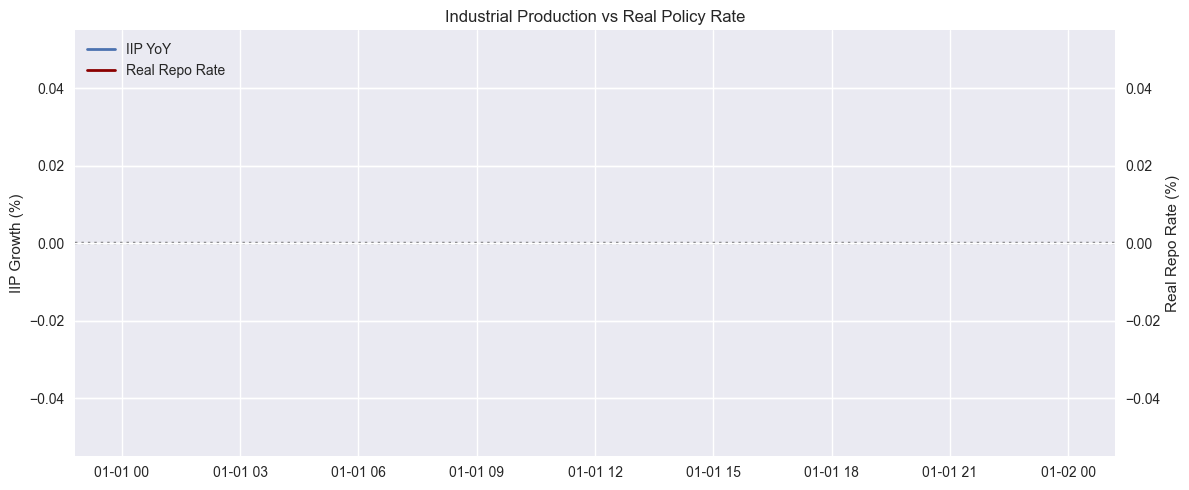

WindowsPath('C:/Users/rahul/Desktop/antigrivity/project 1/india_macro_internship_project/outputs/figures/03_growth_vs_real_rate.png')

In [13]:
# Chart 3: Growth vs real policy rate
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(macro[DATE_COL], macro["iip_yoy"], label="IIP YoY", linewidth=2)
ax1.axhline(0, color="black", linestyle=":", alpha=0.5)
ax1.set_ylabel("IIP Growth (%)")
ax2 = ax1.twinx()
ax2.plot(macro[DATE_COL], macro["real_repo_rate"], label="Real Repo Rate", color="darkred", linewidth=2)
ax2.set_ylabel("Real Repo Rate (%)")
ax1.set_title("Industrial Production vs Real Policy Rate")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
save_fig("03_growth_vs_real_rate.png")

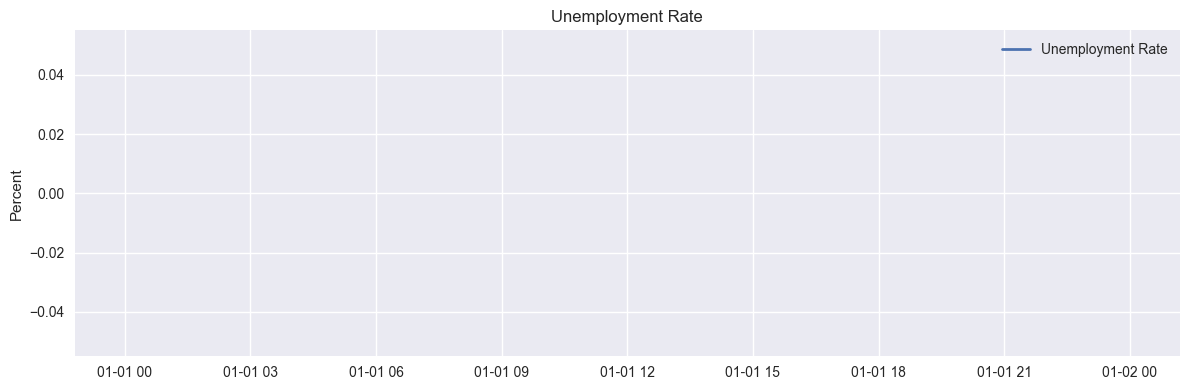

WindowsPath('C:/Users/rahul/Desktop/antigrivity/project 1/india_macro_internship_project/outputs/figures/04_unemployment.png')

In [14]:
# Chart 4: Unemployment
plt.figure(figsize=(12,4))
plt.plot(macro[DATE_COL], macro["unemployment_rate"], linewidth=2, label="Unemployment Rate")
plt.title("Unemployment Rate")
plt.ylabel("Percent")
plt.legend()
save_fig("04_unemployment.png")

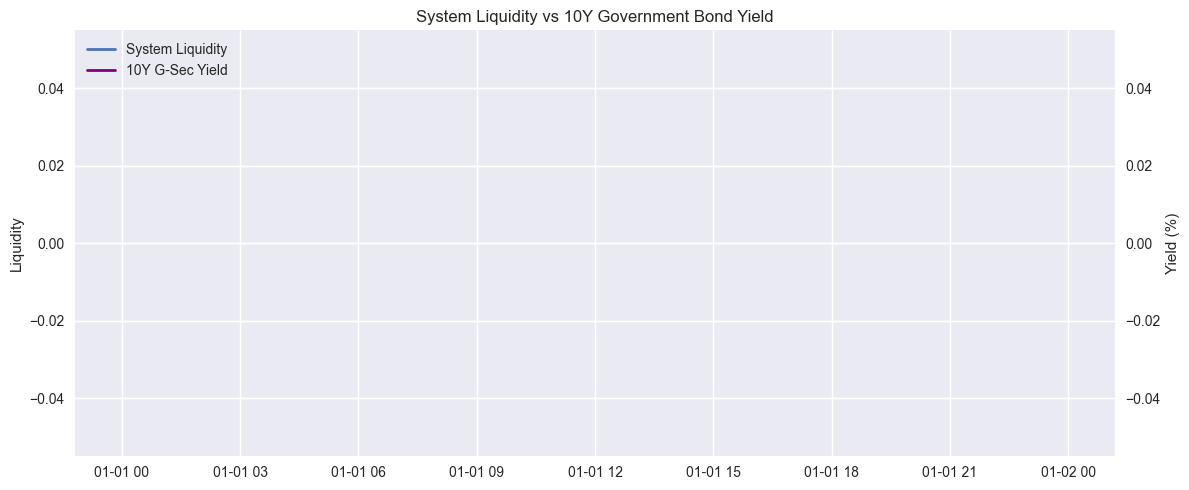

WindowsPath('C:/Users/rahul/Desktop/antigrivity/project 1/india_macro_internship_project/outputs/figures/05_liquidity_vs_yield.png')

In [15]:
# Chart 5: Liquidity vs 10Y yields
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(macro[DATE_COL], macro["system_liquidity"], label="System Liquidity", linewidth=2)
ax1.set_ylabel("Liquidity")
ax2 = ax1.twinx()
ax2.plot(macro[DATE_COL], macro["gsec_10y_yield"], label="10Y G-Sec Yield", color="purple", linewidth=2)
ax2.set_ylabel("Yield (%)")
ax1.set_title("System Liquidity vs 10Y Government Bond Yield")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
save_fig("05_liquidity_vs_yield.png")

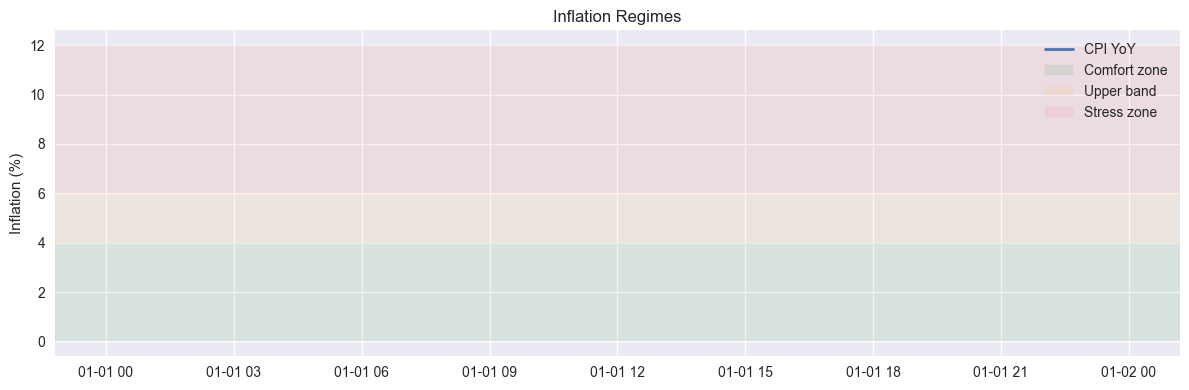

WindowsPath('C:/Users/rahul/Desktop/antigrivity/project 1/india_macro_internship_project/outputs/figures/06_inflation_regimes.png')

In [16]:
# Chart 6: Inflation regime bands
plt.figure(figsize=(12,4))
plt.plot(macro[DATE_COL], macro["cpi_yoy"], linewidth=2, label="CPI YoY")
plt.axhspan(0, 4, color="green", alpha=0.08, label="Comfort zone")
plt.axhspan(4, 6, color="orange", alpha=0.08, label="Upper band")
plt.axhspan(6, 12, color="red", alpha=0.06, label="Stress zone")
plt.title("Inflation Regimes")
plt.ylabel("Inflation (%)")
plt.legend()
save_fig("06_inflation_regimes.png")

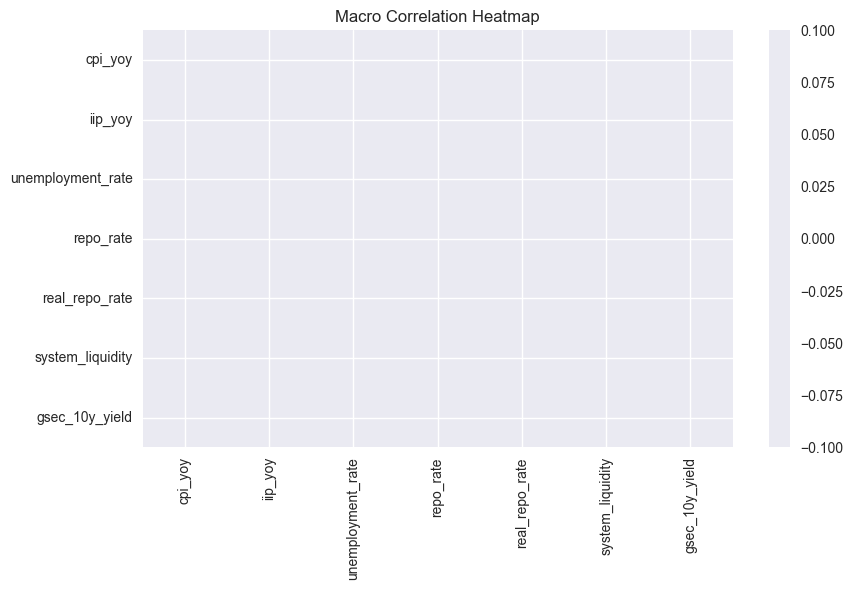

WindowsPath('C:/Users/rahul/Desktop/antigrivity/project 1/india_macro_internship_project/outputs/figures/07_correlation_heatmap.png')

In [17]:
# Chart 7: Correlation heatmap
corr_cols = ["cpi_yoy", "iip_yoy", "unemployment_rate", "repo_rate", "real_repo_rate", "system_liquidity", "gsec_10y_yield"]
corr = macro[corr_cols].corr()

plt.figure(figsize=(9,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Macro Correlation Heatmap")
save_fig("07_correlation_heatmap.png")

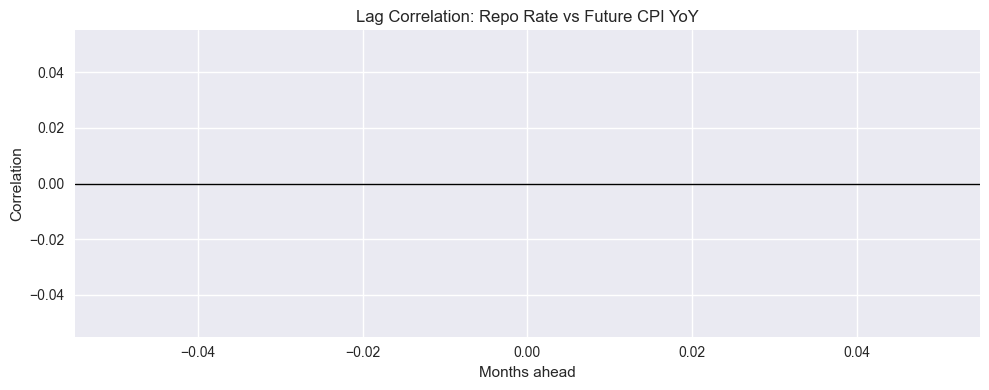

WindowsPath('C:/Users/rahul/Desktop/antigrivity/project 1/india_macro_internship_project/outputs/figures/08_lag_correlation.png')

In [18]:
# Chart 8: Lag correlation between repo rate and future CPI
max_lag = 12
lags = list(range(0, max_lag + 1))
lag_corr = []
for lag in lags:
    lag_corr.append(macro["repo_rate"].corr(macro["cpi_yoy"].shift(-lag)))

plt.figure(figsize=(10,4))
plt.bar(lags, lag_corr)
plt.axhline(0, color="black", linewidth=1)
plt.title("Lag Correlation: Repo Rate vs Future CPI YoY")
plt.xlabel("Months ahead")
plt.ylabel("Correlation")
save_fig("08_lag_correlation.png")

## Step 6 — Forecast inflation

Two models are used:

- **ARIMA** as the transparent baseline
- **Prophet** as the regime-aware model

The split is:
- Train: everything before 2024-01
- Test: 2024-01 onward

In [19]:
forecast_df = macro[[DATE_COL, "cpi_yoy", "tightening_dummy"]].copy()

train = forecast_df[forecast_df[DATE_COL] < pd.Timestamp("2024-01-01")].copy()
test = forecast_df[forecast_df[DATE_COL] >= pd.Timestamp("2024-01-01")].copy()

y_train = train["cpi_yoy"].astype(float)
y_test = test["cpi_yoy"].astype(float)

print(train.shape, test.shape)

(0, 3) (0, 3)


In [20]:
# ADF test
adf_stat, pvalue, usedlag, nobs, crit, icbest = adfuller(y_train.dropna())
adf_table = pd.DataFrame({
    "metric": ["ADF statistic", "p-value", "lags used", "observations"],
    "value": [adf_stat, pvalue, usedlag, nobs]
})
adf_table

ValueError: zero-size array to reduction operation maximum which has no identity

### ARIMA baseline

Rather than hard-coding a single order, this notebook tries a small ARIMA grid and keeps the lowest AIC model. That is a cleaner internship signal than blindly guessing a model order.

In [ ]:
def arima_grid_search(series: pd.Series, p_values=range(0,3), d_values=range(0,2), q_values=range(0,3)):
    best_aic = np.inf
    best_order = None
    best_fit = None
    series = series.dropna().astype(float)
    for order in itertools.product(p_values, d_values, q_values):
        try:
            fit = ARIMA(series, order=order).fit()
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = order
                best_fit = fit
        except Exception:
            continue
    return best_order, best_fit, best_aic

best_order, arima_fit, arima_aic = arima_grid_search(y_train)
best_order, arima_aic

In [ ]:
arima_forecast = arima_fit.forecast(steps=len(y_test))
arima_rmse = np.sqrt(mean_squared_error(y_test, arima_forecast))
arima_mae = mean_absolute_error(y_test, arima_forecast)

print("ARIMA order:", best_order)
print("ARIMA RMSE:", round(arima_rmse, 4))
print("ARIMA MAE:", round(arima_mae, 4))

### Prophet model with a tightening dummy

Prophet needs `ds` and `y`. The `tightening_dummy` is used as a regressor so the model can respond to the monetary regime shift. If Prophet is not installed in your environment, the notebook will skip that block cleanly.

In [ ]:
    test_index = test[DATE_COL].reset_index(drop=True)
    prop_test = prophet_forecast.set_index("ds").loc[test_index, "yhat"].values
    prop_rmse = np.sqrt(mean_squared_error(y_test, prop_test))
    prop_mae = mean_absolute_error(y_test, prop_test)

    prophet_metrics = {
        "rmse": prop_rmse,
        "mae": prop_mae,
    }

    print("Prophet RMSE:", round(prop_rmse, 4))
    print("Prophet MAE:", round(prop_mae, 4))
else:
    print("Prophet is not available in this environment. Install it with pip to run this section.")

In [ ]:
# Forecast comparison plot
plt.figure(figsize=(12,5))
plt.plot(forecast_df[DATE_COL], forecast_df["cpi_yoy"], label="Actual CPI YoY", linewidth=2)
plt.plot(test[DATE_COL], arima_forecast.values, label=f"ARIMA {best_order}", linestyle="--")
if prophet_forecast is not None:
    plt.plot(prophet_forecast["ds"], prophet_forecast["yhat"], label="Prophet", linestyle=":")
plt.axvline(pd.Timestamp("2024-01-01"), color="black", linestyle="--", alpha=0.7)
plt.title("Inflation Forecast Comparison")
plt.ylabel("CPI YoY (%)")
plt.legend()
save_fig("09_forecast_comparison.png")

In [ ]:
forecast_rows = pd.DataFrame({
    "date": test[DATE_COL].values,
    "actual_cpi_yoy": y_test.values,
    "arima_forecast": arima_forecast.values,
})

if prophet_forecast is not None:
    forecast_rows["prophet_forecast"] = prophet_forecast.set_index("ds").loc[test[DATE_COL], "yhat"].values

forecast_rows.to_csv(OUTPUTS / "inflation_forecast.csv", index=False)
forecast_rows.head()

## Step 7 — Final policy synthesis

Write this exactly like a short macro note, not like a blog post.

Use the charts and forecasts above to support the stance:
- policy is mildly restrictive
- inflation has moderated but not cleanly enough to justify aggressive easing
- growth has softened with a lag
- liquidity and yields still point to restraint

### Policy note draft

India’s 2024–25 monetary tightening cycle looks mildly restrictive in real terms. The repo rate is above inflation at several points in the sample, the real policy rate turns positive, and bond yields remain elevated. Inflation has eased with a lag, which is exactly what monetary transmission theory would predict, but the disinflation is not clean enough to justify aggressive easing.

Growth has softened, though not in a disorderly way, which matters for risk and treasury work because it suggests transmission is underway but incomplete. Labour-market stress remains lagged and should not be over-read. On balance, the stance is closer to “hold restrictive” than “cut quickly”.

Key risks remain food inflation, crude oil, global yields, and fiscal slippage.

## What you now have

- raw data ingestion
- separate frequency alignment
- master dataset construction
- macro charts
- inflation forecast
- a policy note skeleton

That is enough to publish on GitHub and cite in interviews.